In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tmdb = pd.read_csv('2026-04-28_tmdb_v2.csv')

In [3]:
tmdb.groupby(['year','genre']).size().unstack(fill_value=0)

genre,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War
year,,,,,,,,,,,,,,,,,
2015,1,3,2,2,1,0,10,2,1,3,1,0,0,0,0,1,1
2016,0,0,4,1,0,0,9,1,0,3,0,0,6,0,0,1,2
2017,1,2,3,2,1,0,9,2,1,2,1,1,2,0,0,2,0
2018,3,3,3,1,2,0,7,0,2,1,0,0,1,2,1,1,0
2019,2,3,4,3,0,0,6,2,3,0,0,0,3,1,1,1,0
2020,2,2,4,0,0,1,6,1,3,0,2,0,6,0,0,0,0
2021,6,2,4,2,1,0,4,0,4,0,1,0,1,2,1,0,0
2022,2,4,5,1,0,1,7,2,3,1,1,0,2,1,0,1,0
2023,3,2,2,3,0,0,6,0,0,4,1,0,1,3,0,0,0


In [4]:
tmdb_counts = tmdb.groupby(['year','genre']).size().unstack(fill_value=0)

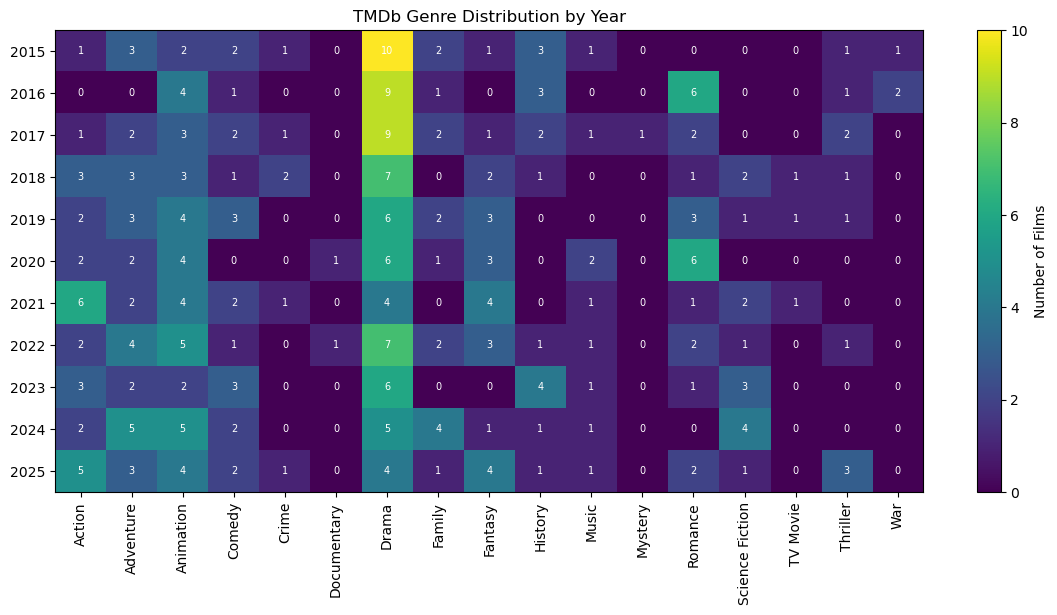

In [5]:
fig, ax = plt.subplots(figsize = (14,6))
heatmap = ax.imshow(tmdb_counts, aspect='auto')

ax.set_xticks(range(len(tmdb_counts.columns)))
ax.set_yticks(range(len(tmdb_counts.index)))
ax.set_xticklabels(tmdb_counts.columns, rotation=90)
ax.set_yticklabels(tmdb_counts.index)

for i in range(len(tmdb_counts.index)):
    for j in range(len(tmdb_counts.columns)):
        val = tmdb_counts.iloc[i, j]
        ax.text(j, i, int(val),
                     ha='center', va='center', fontsize=7, color='white')

ax.set_title('TMDb Genre Distribution by Year')
plt.colorbar(heatmap, ax=ax, label= 'Number of Films')
fig.savefig('tmdbheatmap.jpg')

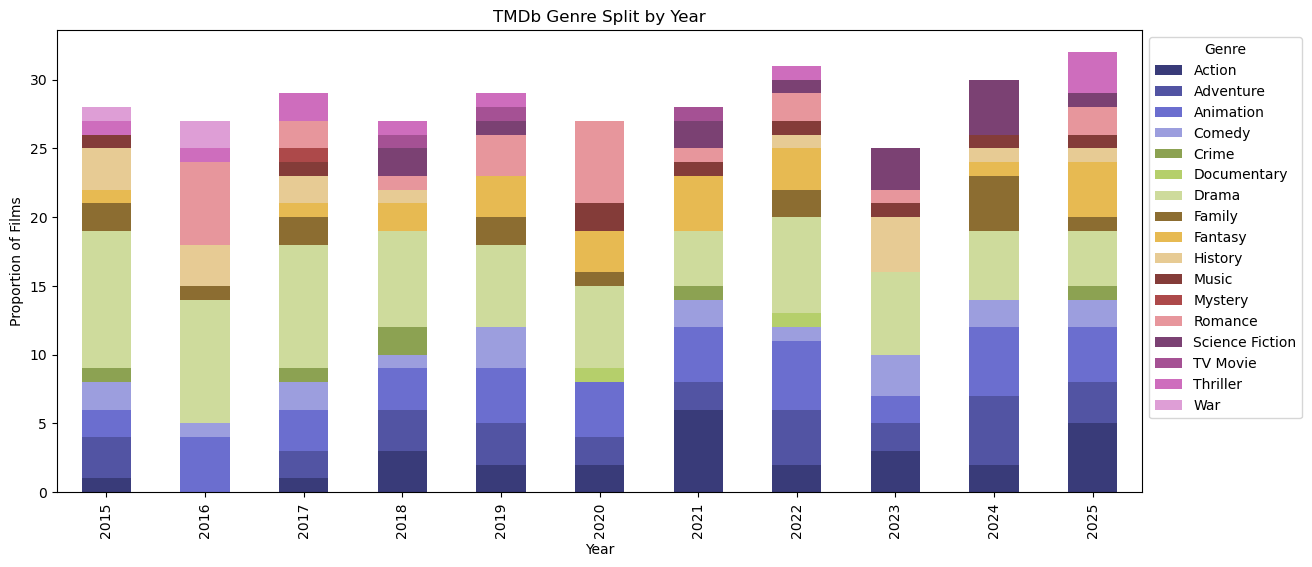

In [6]:
ax = tmdb_counts.plot(kind='bar', figsize=(14,6),stacked=True,colormap='tab20b')
ax.set_title('TMDb Genre Split by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Films')
ax.legend(title='Genre',loc='upper left', bbox_to_anchor=(1,1))
fig.savefig('tmdbstackedbar.jpg')

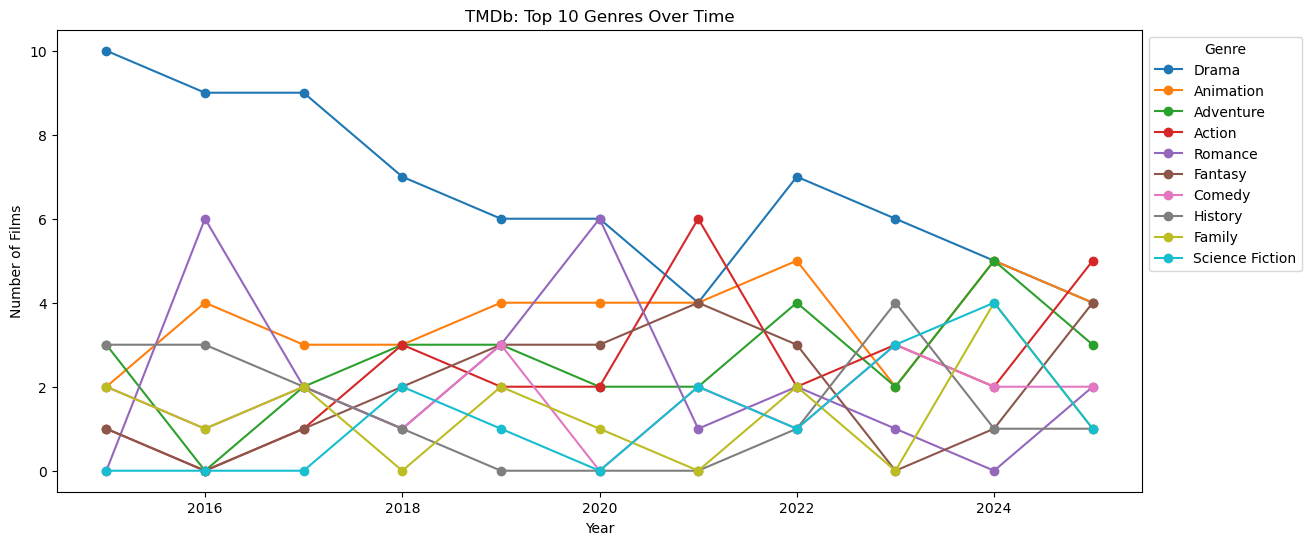

In [7]:
top_genres = tmdb_counts.sum().nlargest(10).index
fig, ax = plt.subplots(figsize=(14,6))

for i in top_genres:
    ax.plot(
        tmdb_counts.index,
        tmdb_counts[i],
        marker='o',
        label=i)
ax.set_title('TMDb: Top 10 Genres Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Films')
ax.legend(title='Genre', bbox_to_anchor=(1,1), loc='upper left')
fig.savefig('tmdblinegraph.jpg')

In [8]:
tmdb_counts = tmdb_counts.sort_index()
percent_changes = {}
for col in tmdb_counts:
    firstval = tmdb_counts[col].iloc[0]
    lastval = tmdb_counts[col].iloc[-1]
    if firstval == 0:
        percent_changes[col] = None
    else:
        percent_changes[col] = ((lastval - firstval)/firstval) *100  

In [9]:
percent = pd.Series(percent_changes)

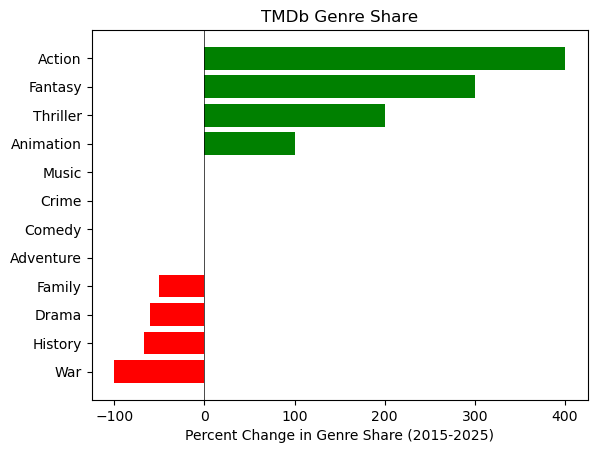

In [10]:
percent = percent.sort_values(ascending=True)

fig, ax = plt.subplots()
colors = ['green' if val >=0 else 'red' for val in percent.values]
bars = ax.barh(percent.index, percent.values, color=colors)
for bar, val in zip(bars, percent.values):
    sign = '+' if val >=0 else '-'
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('TMDb Genre Share')
ax.set_xlabel('Percent Change in Genre Share (2015-2025)')
fig.savefig('tmdbpercentchange.jpg')